# 04 — NUTS without Hessian initialization

**Hypothesis H1**: Let NUTS adapt the mass matrix from identity, with no
Hessian information whatsoever. Long warmup (10k) to give adaptation enough
draws (~3400 in the final window) for 910-dimensional covariance estimation.

**Prediction**: ACF will still not decay because singular geometry defeats
any fixed mass matrix (linear preconditioner). But this establishes the
baseline for "pure Stan" without analytical shortcuts.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Resolve project root
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt_root = cwd / "projects" / "markov-chain-learning"
    if (alt_root / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt_root

if project_root is None:
    raise RuntimeError("Could not locate markov-chain-learning project root")

packages_dir = project_root / "packages"
if str(packages_dir) not in sys.path:
    sys.path.insert(0, str(packages_dir))

from pytorch_models import MarkovTransformer

DATA_DIR = project_root / "experiments" / "single-chain" / "data"
print(f"Project root: {project_root}")
print(f"Data dir: {DATA_DIR}")

Project root: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning
Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


## Load data & model from checkpoint

In [3]:
# Load dataset
data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
sequences = data["sequences"]
data_cfg = data["config"]

VOCAB_SIZE = int(data_cfg["n_states"])
MAX_LEN = int(data_cfg["L"])
PAD_ID = int(data_cfg.get("pad_id", -1))
DGP_REGIME = data_cfg.get("dgp_regime", "unknown")

print(f"DGP regime: {DGP_REGIME}")
print(
    f"Sequences: {tuple(sequences.shape)}, VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}"
)

DGP regime: single
Sequences: (3000, 10), VOCAB_SIZE=5, MAX_LEN=10


In [4]:
# Load trained model from checkpoint
device = torch.device("cpu")
D_MODEL = VOCAB_SIZE * 2

model = MarkovTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    max_len=MAX_LEN,
).to(device)

ckpt = torch.load(DATA_DIR / "checkpoint_single_chain.pt", weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Loaded checkpoint (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")
print(f"Total parameters: {total_params:,}")

Loaded checkpoint (epoch 91, val_loss=1.2716)
Total parameters: 910


In [5]:
# Prepare data tensors for sampling
x_data = sequences[:, :-1].to(device)
y_data = sequences[:, 1:].to(device)
x_data = x_data.clone()
x_data[x_data == PAD_ID] = 0

mle_param = torch.cat([p.flatten() for p in model.parameters()]).detach()
print(f"MLE parameter vector: d = {mle_param.shape[0]}")

MLE parameter vector: d = 910


## Sampling setup

In [6]:
def loss_fn(logits, targets):
    ce = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
        reduction="none",
        ignore_index=PAD_ID,
    )
    ce = ce.view(logits.shape[:-1])
    mask = (targets != PAD_ID).float()
    return (ce * mask).sum() / mask.sum()


def make_prior_logp(mu: torch.Tensor, sigma=10.0):
    """Gaussian prior N(mu, sigma^2 I) — centred at the MAP."""
    mean = mu.detach().clone()

    def prior_logp(params):
        flat = torch.cat([p.flatten() for p in params])
        diff = flat - mean
        return -0.5 * diff.pow(2).sum() / (sigma**2)

    return prior_logp

## NUTS — iterative warmup with persistent mass matrix

Workflow:
1. **Config cell**: set `START_FRESH=True` to begin from identity, or `False` to
   load the last saved mass matrix from disk and continue adapting from there.
2. **Warmup cell**: runs warmup only (0 production samples). Re-run as many
   times as you want — each run loads the current M, warms up, saves the new M.
3. **Save cell**: persists the adapted M to disk (automatic at end of warmup).
4. **Production cell**: uses the saved M with no further adaptation.

In [7]:
import collections

from torch_bdn.bn import BayesianNet
from torch_bdn.sampling import NUTS, Perturb, Sampler

# ============================================================================
# CONFIG - toggle this flag between runs
# ============================================================================
START_FRESH = True  # True -> identity M; False -> load from disk

SIGMA_PRIOR = 10.0
N_WARMUP = 10000
MAX_TREE_DEPTH = 7
MASS_MATRIX_PATH = DATA_DIR / "adapted_mass_matrix_no_hessian.pt"


def print_mass_matrix_diagnostics(M: torch.Tensor, name: str = "M"):
    """Print conditioning and structure diagnostics for a mass matrix."""
    M_cpu = M.detach().cpu().float()
    eigvals = torch.linalg.eigvalsh(M_cpu)
    sv = torch.linalg.svdvals(M_cpu)

    min_eig = float(eigvals.min())
    max_eig = float(eigvals.max())
    cond = float(sv[0] / sv[-1]) if sv[-1] > 0 else float("inf")
    symmetry_err = float((M_cpu - M_cpu.T).abs().max())
    diag_vals = torch.diagonal(M_cpu)

    print(f"{name} diagnostics:")
    print(f"  shape={tuple(M_cpu.shape)}")
    print(f"  eig min/max = [{min_eig:.4e}, {max_eig:.4e}]")
    print(f"  singular min/max = [{float(sv[-1]):.4e}, {float(sv[0]):.4e}]")
    print(f"  condition number = {cond:.2e}")
    print(f"  symmetry max error = {symmetry_err:.3e}")
    print(
        f"  diag stats (min/median/max) = [{float(diag_vals.min()):.4e}, "
        f"{float(diag_vals.median()):.4e}, {float(diag_vals.max()):.4e}]"
    )
    if min_eig <= 0:
        print("  WARNING: matrix is not strictly SPD")


# Load or initialize mass matrix
if START_FRESH:
    mass_matrix = None
    print(f"Starting from IDENTITY mass matrix (d={mle_param.shape[0]})")
else:
    if MASS_MATRIX_PATH.exists():
        mass_matrix = torch.load(MASS_MATRIX_PATH, weights_only=True)
        print(f"Loaded mass matrix from {MASS_MATRIX_PATH.name}")
        print_mass_matrix_diagnostics(mass_matrix, name="Loaded M")
    else:
        mass_matrix = None
        print(
            f"No saved mass matrix found at {MASS_MATRIX_PATH.name}, starting from identity"
        )

bn = BayesianNet(
    model, loss_fn, make_prior_logp(mle_param, sigma=SIGMA_PRIOR), compile=True
)

Starting from IDENTITY mass matrix (d=910)


In [8]:
# ============================================================================
# WARMUP ONLY - re-run this cell as many times as you want
# Each run adapts from the current mass_matrix and saves the result.
# ============================================================================

warmup_result = Sampler(bn, x_data, y_data).sample(
    config=NUTS(
        n_warmup=N_WARMUP,
        step_size=0.01,
        max_tree_depth=MAX_TREE_DEPTH,
        target_accept=0.69,
        mass_matrix=mass_matrix,
        adapt_mass_matrix=True,
    ),
    n_samples=1,  # just 1 sample to finish; we only care about adaptation
    n_chains=1,
    init_strategy=Perturb(scale=0.1),
    n_cores=1,
)

# Extract adapted mass matrix for next iteration
diag = warmup_result.chains[0].diagnostics
adapted_M = diag.get("adapted_mass_matrix")
adapted_step_size = diag.get("adapted_step_size", diag["step_size"])

if adapted_M is not None:
    mass_matrix = adapted_M  # update in-memory for re-runs
    torch.save(adapted_M, MASS_MATRIX_PATH)
    svd = torch.linalg.svdvals(adapted_M)
    print(f"✓ Warmup complete. Saved mass matrix to {MASS_MATRIX_PATH.name}")
    print(f"  cond={svd[0] / svd[-1]:.1f}, σ_min={svd[-1]:.4e}, σ_max={svd[0]:.4e}")
    print(f"  adapted ε = {adapted_step_size:.4e}")
    print(f"  accept = {warmup_result.chains[0].acceptance_rate:.3f}")
else:
    print("⚠ No adapted mass matrix returned")
    print(
        f"  ε = {adapted_step_size:.4e}, accept = {warmup_result.chains[0].acceptance_rate:.3f}"
    )

# Show adaptation details
for mu in diag.get("warmup_mass_updates", []):
    print(
        f"    M update @ step {mu['step']}: type={mu['type']}, n_draws={mu['n_draws']}"
    )

  [NUTS warmup] step 10/10001  ε=1.01e-02  depth=7 (hit max)  L=127  α=0.62  divs=3/10  mass=identity
  [NUTS warmup] step 20/10001  ε=5.96e-03  depth=7 (hit max)  L=127  α=0.64  divs=0/10  mass=identity
  [NUTS warmup] step 30/10001  ε=2.71e-03  depth=7 (hit max)  L=127  α=0.71  divs=0/10  mass=identity
  [NUTS warmup] step 40/10001  ε=3.93e-03  depth=7 (hit max)  L=127  α=0.69  divs=0/10  mass=identity
  [NUTS warmup] step 50/10001  ε=2.97e-03  depth=7 (hit max)  L=127  α=0.60  divs=0/10  mass=identity
  [NUTS warmup] step 60/10001  ε=1.46e-03  depth=7 (hit max)  L=127  α=0.71  divs=0/10  mass=identity
  [NUTS warmup] step 70/10001  ε=1.26e-03  depth=7 (hit max)  L=127  α=0.59  divs=0/10  mass=identity
  [NUTS warmup] step 80/10001  ε=3.29e-03  depth=7 (hit max)  L=127  α=0.59  divs=2/10  mass=identity
  [NUTS warmup] step 90/10001  ε=3.54e-03  depth=7 (hit max)  L=127  α=0.66  divs=0/10  mass=identity
  [NUTS warmup] step 100/10001  ε=4.17e-04  depth=7 (hit max)  L=127  α=0.70  divs

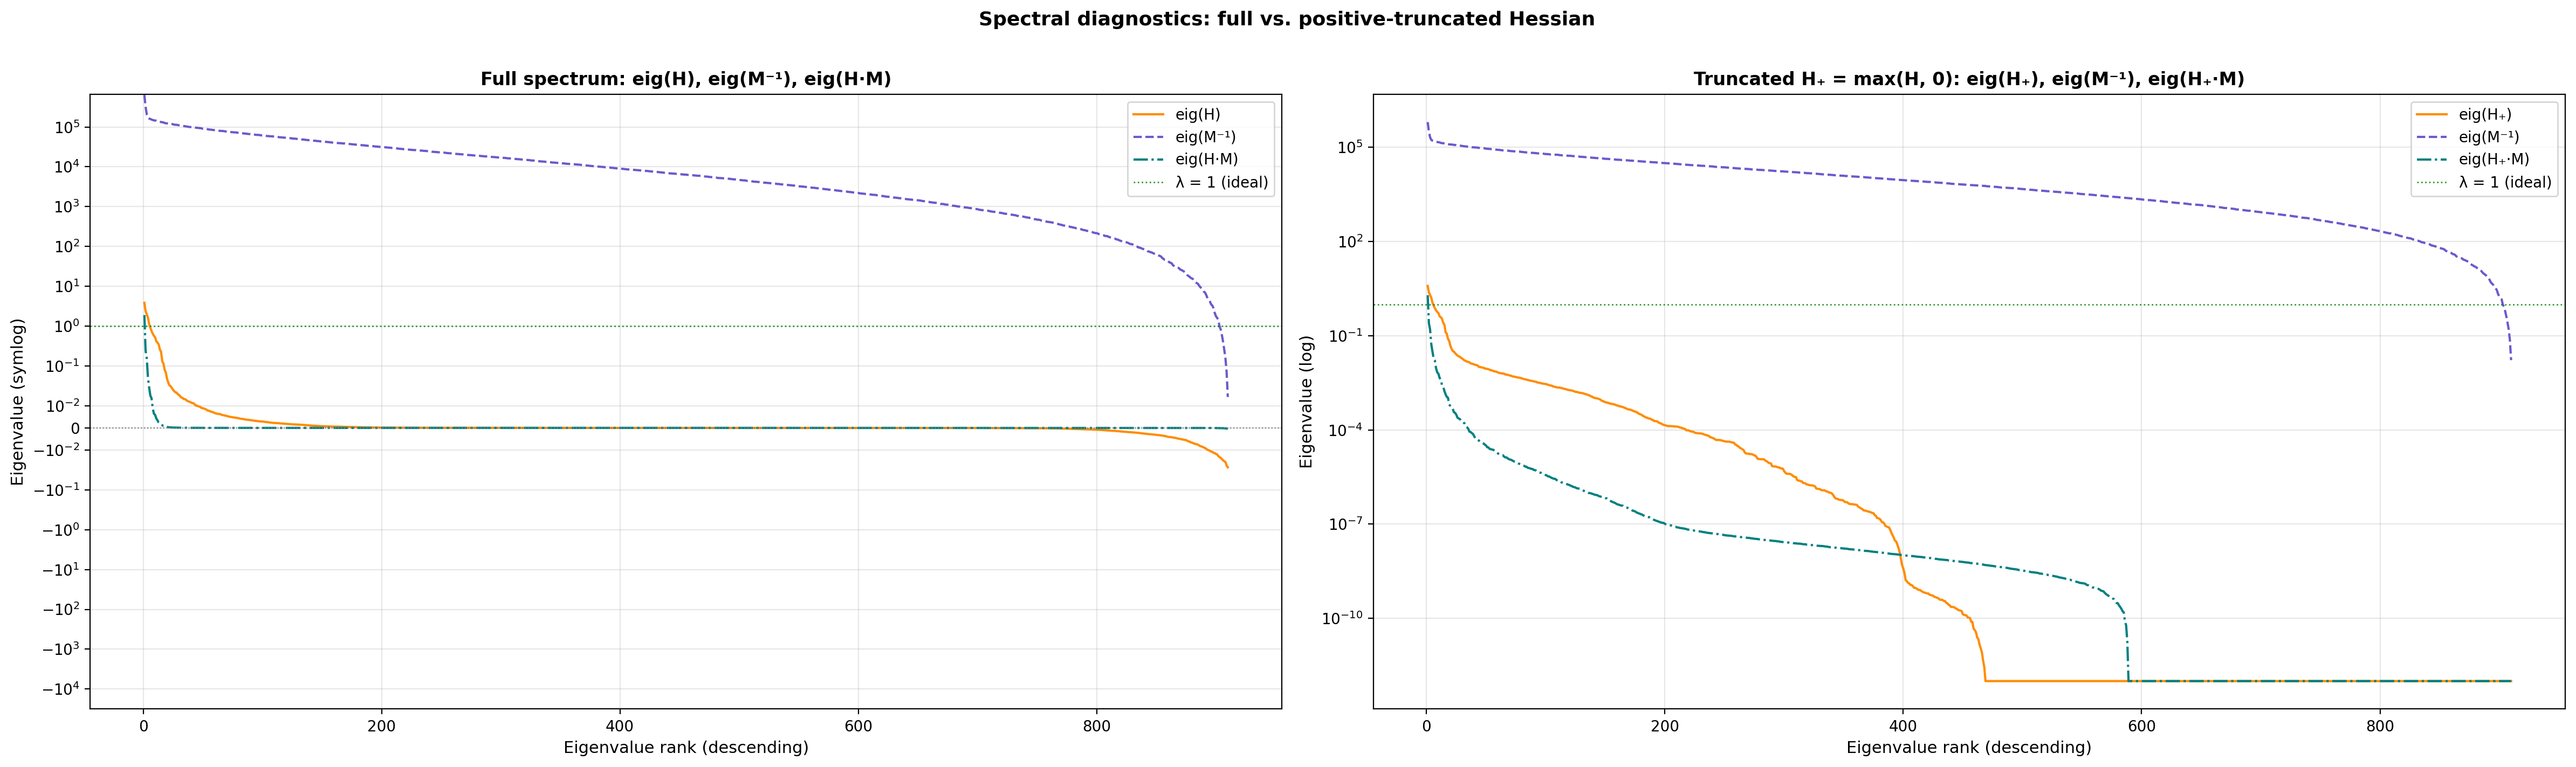

eig(M⁻¹) / eig(H) for top 480 positive H modes:
  min: 1.0545e+05, max: 5.9187e+13, median: 4.4881e+08

eig(H) range:     [-2.7144e-02, 3.8510e+00]
eig(M⁻¹) range:   [1.6639e-02, 6.3601e+05]
eig(H·M) range:   [-4.8860e-04, 1.8937e+00]

eig(H₊) range:    [0.0000e+00, 3.8510e+00]
eig(H₊·M) range:  [-1.5056e-07, 1.9517e+00]

H₊ has 468 positive modes (rest truncated to 0)
eig(H₊·M) within [0.5, 1.5]: 0/910


In [68]:
# -- Spectral comparison: eig(H), eig(M^{-1}), and eig(H·M) on one plot --
# Left: full signed spectrum (symlog). Right: truncated H₊ = max(H, 0) on log scale.

M_for_diag = (
    adapted_M if "adapted_M" in globals() and adapted_M is not None else mass_matrix
)

if M_for_diag is not None:
    M_cpu = M_for_diag.detach().cpu().float()
    eigvals_M = torch.linalg.eigvalsh(M_cpu)

    # M^{-1} eigenvalues = 1 / eigenvalues of M
    eig_Minv = 1.0 / eigvals_M.clamp(min=1e-10)
    eig_Minv_sorted = torch.sort(eig_Minv, descending=True).values

    # Hessian eigenvalues (reuse cached)
    if "H_mle" not in globals() or H_mle is None:
        from torch_bdn.bn.bayesian_net import approx_hessian

        H_mle = approx_hessian(model, loss_fn, x_data, y_data, chunk_size=10240).cpu()
    H_cpu = H_mle.detach().cpu().float()
    eig_h_sorted = torch.sort(torch.linalg.eigvalsh(H_cpu), descending=True).values

    # Reuse eig_HM_sorted from the previous cell
    rank_idx = torch.arange(1, eig_h_sorted.numel() + 1)

    # ── Truncated Hessian: H₊ = V diag(max(λ,0)) V^T ──
    eigvals_h_full, eigvecs_h = torch.linalg.eigh(H_cpu)
    eigvals_h_trunc = eigvals_h_full.clamp(min=0)  # zero out negative eigenvalues
    H_trunc = eigvecs_h @ torch.diag(eigvals_h_trunc) @ eigvecs_h.T

    # eig(H₊) sorted descending
    eig_Htrunc_sorted = torch.sort(eigvals_h_trunc, descending=True).values

    # eig(H₊ · M) via similarity: M^{1/2} H₊ M^{1/2}
    eigvals_m_loc, eigvecs_m_loc = torch.linalg.eigh(M_cpu)
    eigvals_m_safe = eigvals_m_loc.clamp(min=1e-10)
    M_sqrt = eigvecs_m_loc @ torch.diag(eigvals_m_safe.sqrt()) @ eigvecs_m_loc.T
    HtruncM_sym = M_sqrt @ H_trunc @ M_sqrt
    eig_HtruncM = torch.linalg.eigvalsh(HtruncM_sym)
    eig_HtruncM_sorted = torch.sort(eig_HtruncM, descending=True).values

    # ══════════════════════════════════════════════════════════════════════
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(24, 7), sharex=True)

    # ── Left panel: full signed spectrum (symlog) ──
    ax_left.plot(
        rank_idx.numpy(),
        eig_h_sorted.numpy(),
        color="darkorange",
        lw=1.5,
        label="eig(H)",
    )
    ax_left.plot(
        rank_idx.numpy(),
        eig_Minv_sorted.numpy(),
        color="slateblue",
        lw=1.5,
        ls="--",
        label="eig(M⁻¹)",
    )
    ax_left.plot(
        rank_idx.numpy(),
        eig_HM_sorted.numpy(),
        color="teal",
        lw=1.5,
        ls="-.",
        label="eig(H·M)",
    )
    ax_left.axhline(1, color="green", lw=1.0, ls=":", alpha=0.8, label="λ = 1 (ideal)")
    ax_left.axhline(0, color="gray", lw=0.8, ls=":")

    ax_left.set_yscale("symlog", linthresh=1e-2, linscale=0.5)
    ax_left.set_xlabel("Eigenvalue rank (descending)", fontsize=11)
    ax_left.set_ylabel("Eigenvalue (symlog)", fontsize=11)
    ax_left.set_title(
        "Full spectrum: eig(H), eig(M⁻¹), eig(H·M)", fontsize=12, fontweight="bold"
    )
    ax_left.grid(True, alpha=0.3)
    ax_left.legend(fontsize=10)

    # ── Right panel: truncated H₊ on log scale ──
    # Only plot positive values (log scale requires > 0)
    # For H₊: skip the zero eigenvalues
    pos_mask_Ht = eig_Htrunc_sorted > 1e-12
    pos_mask_HtM = eig_HtruncM_sorted > 1e-12

    ax_right.plot(
        rank_idx.numpy(),
        eig_Htrunc_sorted.clamp(min=1e-12).numpy(),
        color="darkorange",
        lw=1.5,
        label="eig(H₊)",
    )
    ax_right.plot(
        rank_idx.numpy(),
        eig_Minv_sorted.numpy(),
        color="slateblue",
        lw=1.5,
        ls="--",
        label="eig(M⁻¹)",
    )
    ax_right.plot(
        rank_idx.numpy(),
        eig_HtruncM_sorted.clamp(min=1e-12).numpy(),
        color="teal",
        lw=1.5,
        ls="-.",
        label="eig(H₊·M)",
    )
    ax_right.axhline(1, color="green", lw=1.0, ls=":", alpha=0.8, label="λ = 1 (ideal)")

    ax_right.set_yscale("log")
    ax_right.set_xlabel("Eigenvalue rank (descending)", fontsize=11)
    ax_right.set_ylabel("Eigenvalue (log)", fontsize=11)
    ax_right.set_title(
        "Truncated H₊ = max(H, 0): eig(H₊), eig(M⁻¹), eig(H₊·M)",
        fontsize=12,
        fontweight="bold",
    )
    ax_right.grid(True, alpha=0.3)
    ax_right.legend(fontsize=10)

    fig.suptitle(
        "Spectral diagnostics: full vs. positive-truncated Hessian",
        fontsize=13,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

    # ── Summary ──
    n_h_pos = (eig_h_sorted > 0).sum().item()
    ratio = eig_Minv_sorted[:n_h_pos] / eig_h_sorted[:n_h_pos].clamp(min=1e-10)
    print(f"eig(M⁻¹) / eig(H) for top {n_h_pos} positive H modes:")
    print(
        f"  min: {ratio.min():.4e}, max: {ratio.max():.4e}, median: {ratio.median():.4e}"
    )
    print(f"\neig(H) range:     [{eig_h_sorted[-1]:.4e}, {eig_h_sorted[0]:.4e}]")
    print(f"eig(M⁻¹) range:   [{eig_Minv_sorted[-1]:.4e}, {eig_Minv_sorted[0]:.4e}]")
    print(f"eig(H·M) range:   [{eig_HM_sorted[-1]:.4e}, {eig_HM_sorted[0]:.4e}]")
    print(
        f"\neig(H₊) range:    [{eig_Htrunc_sorted[-1]:.4e}, {eig_Htrunc_sorted[0]:.4e}]"
    )
    print(
        f"eig(H₊·M) range:  [{eig_HtruncM_sorted[-1]:.4e}, {eig_HtruncM_sorted[0]:.4e}]"
    )
    n_Ht_pos = (eig_Htrunc_sorted > 1e-12).sum().item()
    n_HtM_near1 = ((eig_HtruncM_sorted - 1).abs() < 0.5).sum().item()
    print(f"\nH₊ has {n_Ht_pos} positive modes (rest truncated to 0)")
    print(f"eig(H₊·M) within [0.5, 1.5]: {n_HtM_near1}/{eig_HtruncM_sorted.numel()}")

In [72]:
# ══════════════════════════════════════════════════════════════════════════════
# PRODUCTION SAMPLING — uses saved mass matrix, no further adaptation
# ══════════════════════════════════════════════════════════════════════════════
N_SAMPLES = 10000

# Load the latest mass matrix from disk
mass_matrix_prod = torch.load(MASS_MATRIX_PATH, weights_only=True)
print(f"Loaded mass matrix from {MASS_MATRIX_PATH.name}")

result = Sampler(bn, x_data, y_data).sample(
    config=NUTS(
        n_warmup=0,
        step_size=adapted_step_size,
        max_tree_depth=MAX_TREE_DEPTH,
        target_accept=0.69,
        mass_matrix=mass_matrix_prod,
        adapt_mass_matrix=False,
        # adapt_step_size=False,
    ),
    n_samples=N_SAMPLES,
    n_chains=1,
    init_strategy=Perturb(scale=0.1),
    n_cores=1,
)

# ── Summary ──
for ci, ch in enumerate(result.chains):
    diag = ch.diagnostics
    tree_depths = diag.get("tree_depths", [])
    leapfrog_counts = diag.get("leapfrog_counts", [])
    n_hit_max = diag.get("n_hit_max_depth", 0)
    n_div = diag.get("n_divergences", 0)
    n_samp = len(tree_depths)
    print(
        f"Chain {ci}: accept={ch.acceptance_rate:.3f}  "
        f"ε={diag.get('step_size', '?'):.4e}  "
        f"mean_depth={diag.get('mean_tree_depth', 0):.1f}  "
        f"mean_L={diag.get('mean_leapfrog', 0):.0f}"
    )
    print(f"  max_depth_hits={n_hit_max}/{n_samp}  divergences={n_div}/{n_samp}")
    if tree_depths:
        depth_counts = collections.Counter(tree_depths)
        print(f"  Tree depth distribution: {dict(sorted(depth_counts.items()))}")
    if leapfrog_counts:
        print(
            f"  Leapfrog: min={min(leapfrog_counts)} "
            f"median={sorted(leapfrog_counts)[len(leapfrog_counts) // 2]} "
            f"max={max(leapfrog_counts)} "
            f"total={sum(leapfrog_counts)}"
        )

Loaded mass matrix from adapted_mass_matrix_no_hessian.pt
  [NUTS sample] step 10/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 20/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 30/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 40/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 50/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 60/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 70/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 80/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 90/10000  ε=3.94e-04  depth=7 (hit max)  L=127  α=1.00  divs=0/10  mass=full
  [NUTS sample] step 100/10000  ε=3.94e-04  depth=7 (hit max

In [73]:
# ── Persist production samples ──
nuts_path = DATA_DIR / "nuts_samples_no_hessian.pt"

chains_payload = [
    {
        "parameters": torch.stack(ch.parameters).cpu(),
        "acceptance_rate": ch.acceptance_rate,
        "diagnostics": ch.diagnostics,
    }
    for ch in result.chains
]

torch.save(
    {
        "chains": chains_payload,
        "config": {
            "n_chains": 1,
            "n_warmup": N_WARMUP,
            "n_samples": N_SAMPLES,
            "sigma_prior": SIGMA_PRIOR,
            "dgp_regime": DGP_REGIME,
            "mass_matrix_init": "identity" if START_FRESH else "loaded",
            "adapt_mass_matrix": True,
        },
        "mle_param": mle_param.cpu(),
        "mass_matrix_path": str(MASS_MATRIX_PATH),
    },
    nuts_path,
)
print(f"✓ Saved to {nuts_path}")
print(f"  1 chain × {N_SAMPLES} samples × d={mle_param.shape[0]}")

✓ Saved to /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/nuts_samples_no_hessian.pt
  1 chain × 10000 samples × d=910


## ACF analysis

Compute ACF in the Hessian eigenbasis to see if degenerate vs non-degenerate
directions behave differently. We compute the Hessian here ONLY for the
eigenbasis (diagnostic purposes) — it was NOT used during sampling.

In [74]:
# Compute Hessian eigenbasis FOR DIAGNOSTICS ONLY (not used in sampling)
from torch_bdn.bn.bayesian_net import approx_hessian

print("Computing Hessian eigenbasis for ACF diagnostic...")
H = approx_hessian(model, loss_fn, x_data, y_data, chunk_size=10240).cpu()
eigvals, eigvecs = torch.linalg.eigh(H)

eigval_threshold = eigvals.max().item() * 1e-3
n_nd = int((eigvals.abs() > eigval_threshold).sum())
n_degen = eigvals.shape[0] - n_nd
print(f"Hessian: λ ∈ [{eigvals[0]:.2e}, {eigvals[-1]:.2e}]")
print(f"  {n_nd} non-degenerate directions, {n_degen} degenerate directions")

Computing Hessian eigenbasis for ACF diagnostic...
Hessian: λ ∈ [-2.71e-02, 3.85e+00]
  137 non-degenerate directions, 773 degenerate directions


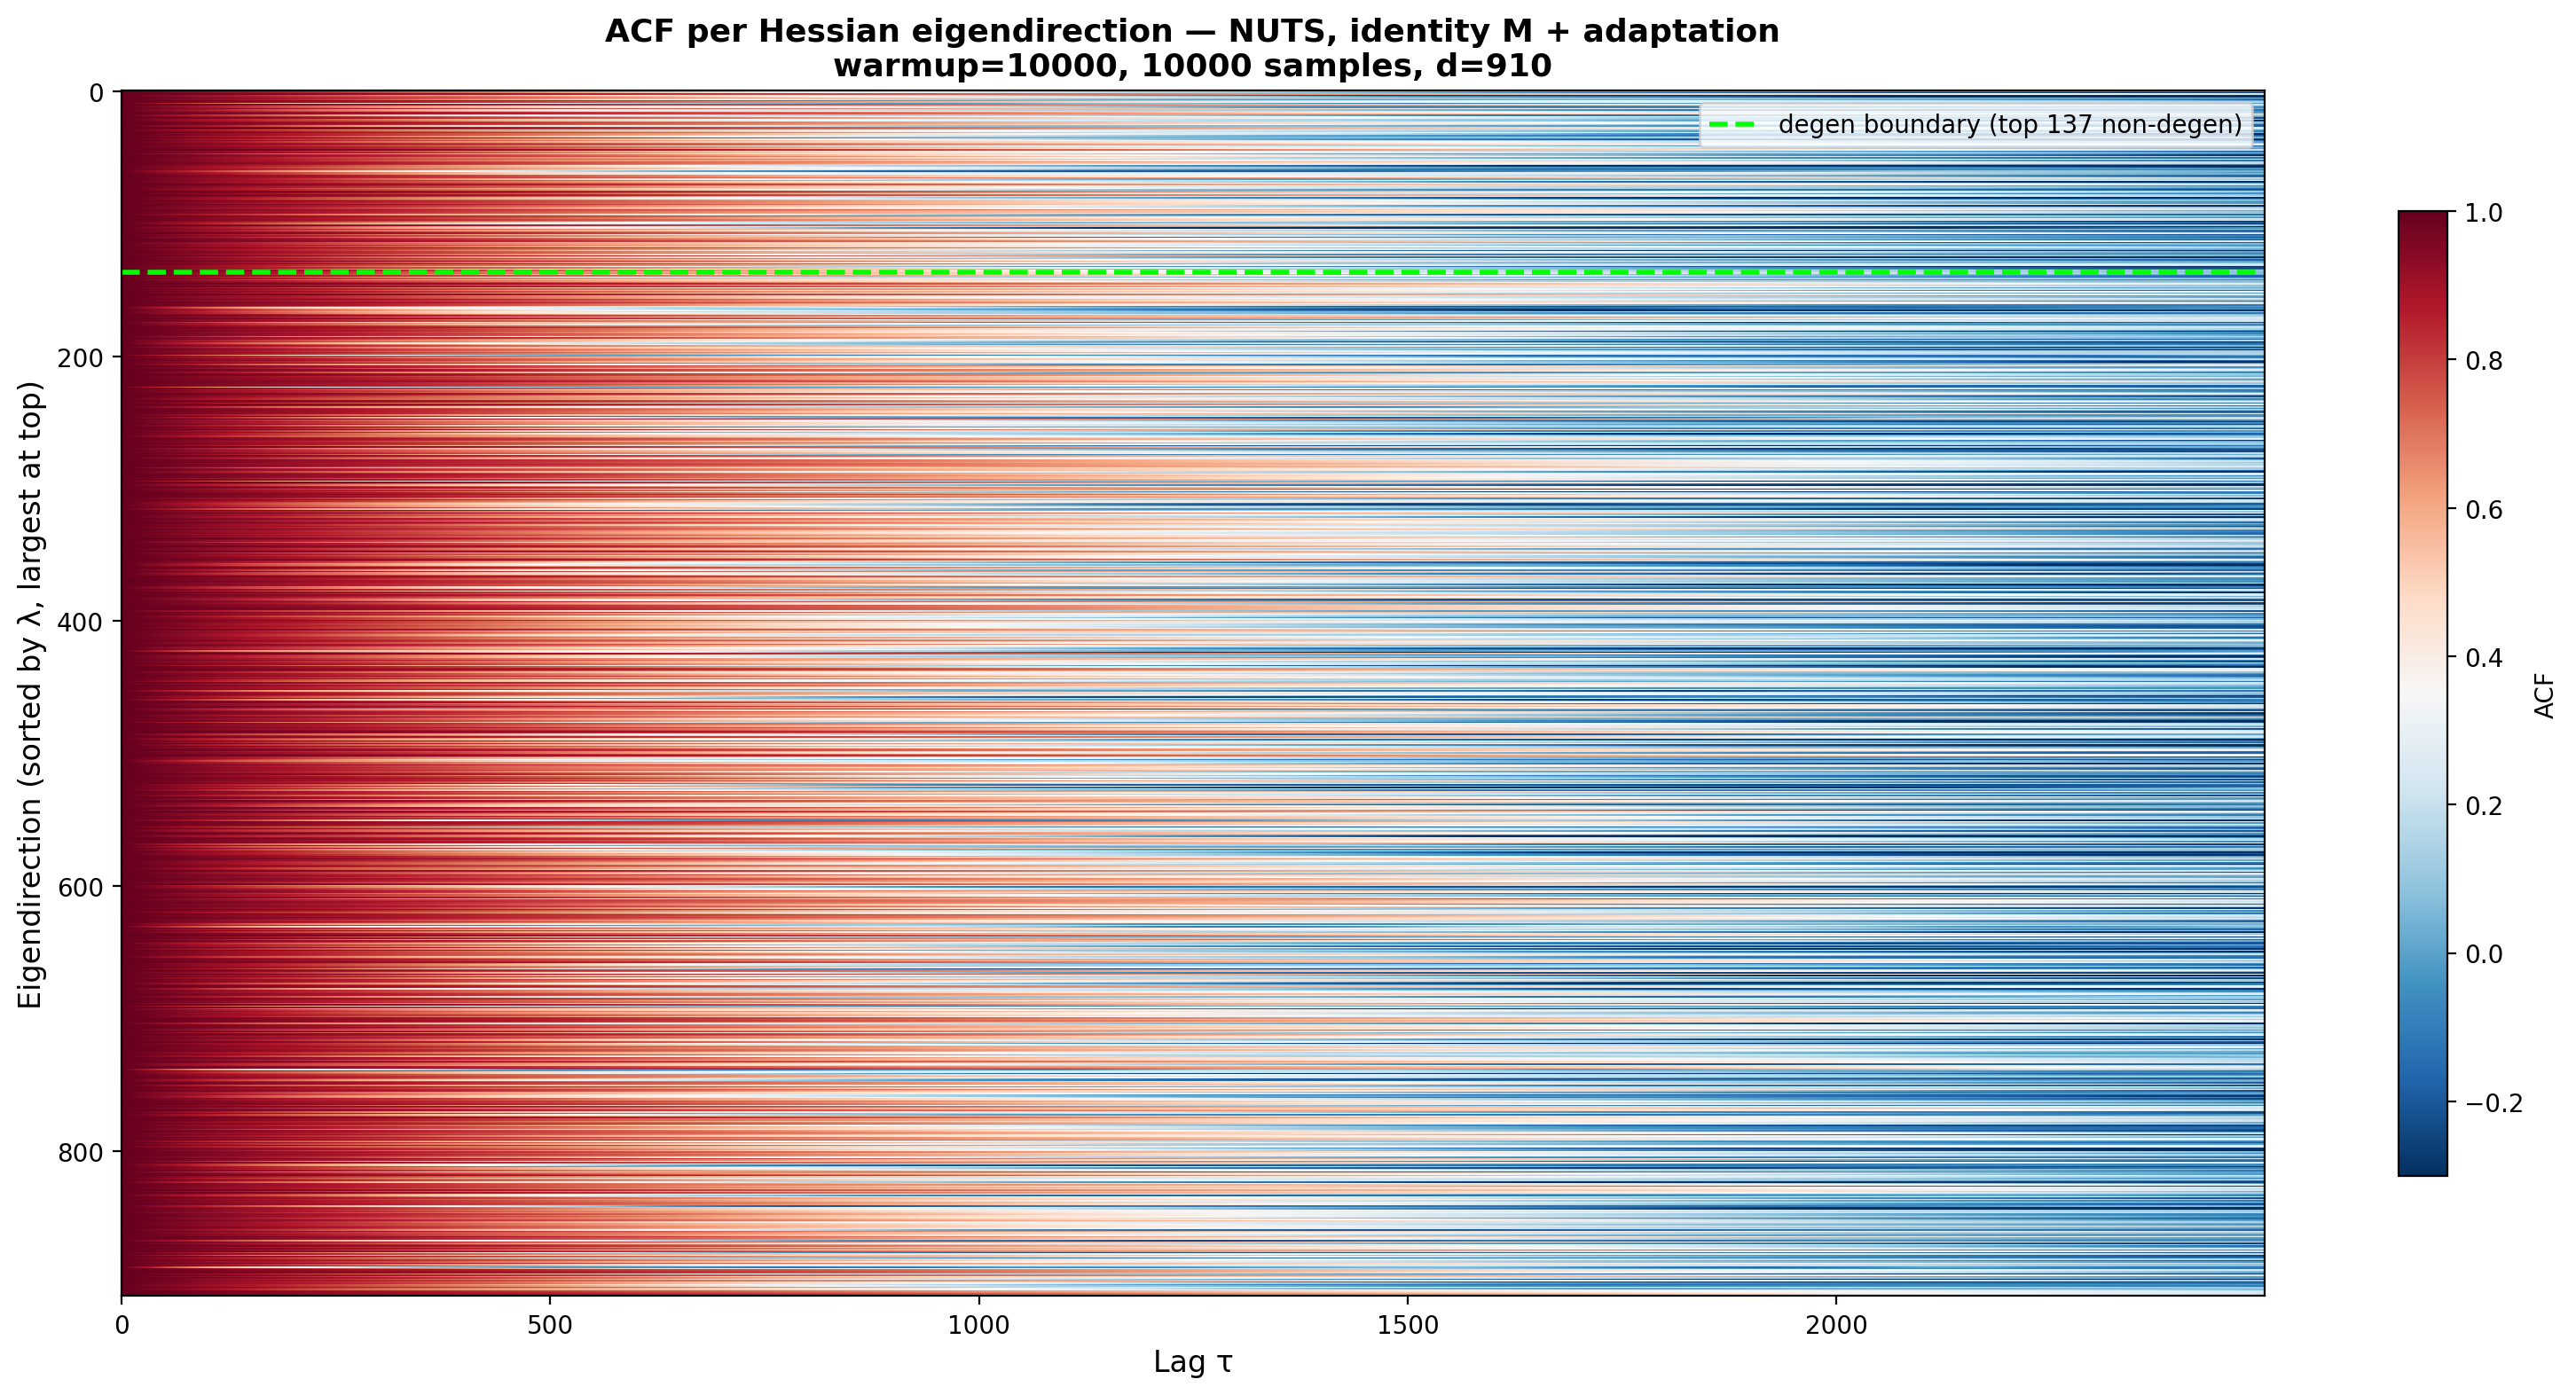


ACF at lag 10:   median=0.994,  max=0.999
ACF at lag 50:   median=0.968,  max=0.992
ACF at lag 200:  median=0.879,  max=0.967

ACF@50 non-degen (137 dirs): median=0.967, max=0.992
ACF@50 degenerate (773 dirs): median=0.969, max=0.992


In [76]:
# ── ACF per Hessian eigendirection ──
V = eigvecs.cpu().float()
MAX_LAG = min(6000, N_SAMPLES // 4)


def compute_acf_eigenbasis(samples_tensor, V, max_lag):
    """Project samples into eigenbasis, compute ACF per direction via FFT."""
    z = samples_tensor @ V
    d = z.shape[1]
    acf = torch.zeros(d, max_lag)
    for j in range(d):
        x = z[:, j]
        x = x - x.mean()
        var = x.var()
        if var < 1e-20:
            continue
        n = x.shape[0]
        padded = torch.zeros(2 * n)
        padded[:n] = x
        ft = torch.fft.rfft(padded)
        acov = torch.fft.irfft(ft * ft.conj())[:n] / n
        acf[j, :max_lag] = acov[:max_lag] / acov[0].clamp(min=1e-20)
    return acf


sort_idx = torch.argsort(eigvals.cpu(), descending=True)
eigvals_sorted = eigvals.cpu()[sort_idx]

samps = torch.stack(result.chains[0].parameters).cpu().float()
acf_sorted = compute_acf_eigenbasis(samps, V, MAX_LAG)[sort_idx]

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(
    acf_sorted.numpy(),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=1.0,
    interpolation="nearest",
    origin="upper",
)
ax.set_xlabel("Lag τ", fontsize=12)
ax.set_ylabel("Eigendirection (sorted by λ, largest at top)", fontsize=12)
ax.set_title(
    f"ACF per Hessian eigendirection — NUTS, identity M + adaptation\n"
    f"warmup={N_WARMUP}, {N_SAMPLES} samples, d={mle_param.shape[0]}",
    fontsize=13,
    fontweight="bold",
)

if 0 < n_nd < samps.shape[1]:
    ax.axhline(
        n_nd - 0.5,
        color="lime",
        lw=2,
        ls="--",
        label=f"degen boundary (top {n_nd} non-degen)",
    )
    ax.legend(loc="upper right", fontsize=10)

plt.colorbar(im, ax=ax, shrink=0.8, label="ACF")
plt.tight_layout()
plt.show()

# Summary statistics
acf_at_10 = acf_sorted[:, min(10, MAX_LAG - 1)]
acf_at_50 = acf_sorted[:, min(50, MAX_LAG - 1)]
acf_at_200 = acf_sorted[:, min(200, MAX_LAG - 1)]
print(f"\nACF at lag 10:   median={acf_at_10.median():.3f},  max={acf_at_10.max():.3f}")
print(f"ACF at lag 50:   median={acf_at_50.median():.3f},  max={acf_at_50.max():.3f}")
print(f"ACF at lag 200:  median={acf_at_200.median():.3f},  max={acf_at_200.max():.3f}")

# Separate stats for non-degen vs degen
acf50_nd = acf_sorted[:n_nd, min(50, MAX_LAG - 1)]
acf50_dg = acf_sorted[n_nd:, min(50, MAX_LAG - 1)]
print(
    f"\nACF@50 non-degen ({n_nd} dirs): median={acf50_nd.median():.3f}, max={acf50_nd.max():.3f}"
)
print(
    f"ACF@50 degenerate ({n_degen} dirs): median={acf50_dg.median():.3f}, max={acf50_dg.max():.3f}"
)

ESS across all 910 directions:
  min=2.9, median=4.8, max=29.5

ESS non-degenerate (137 dirs):
  min=3.1, median=5.0, max=16.7

ESS degenerate (773 dirs):
  min=2.9, median=4.8, max=29.5


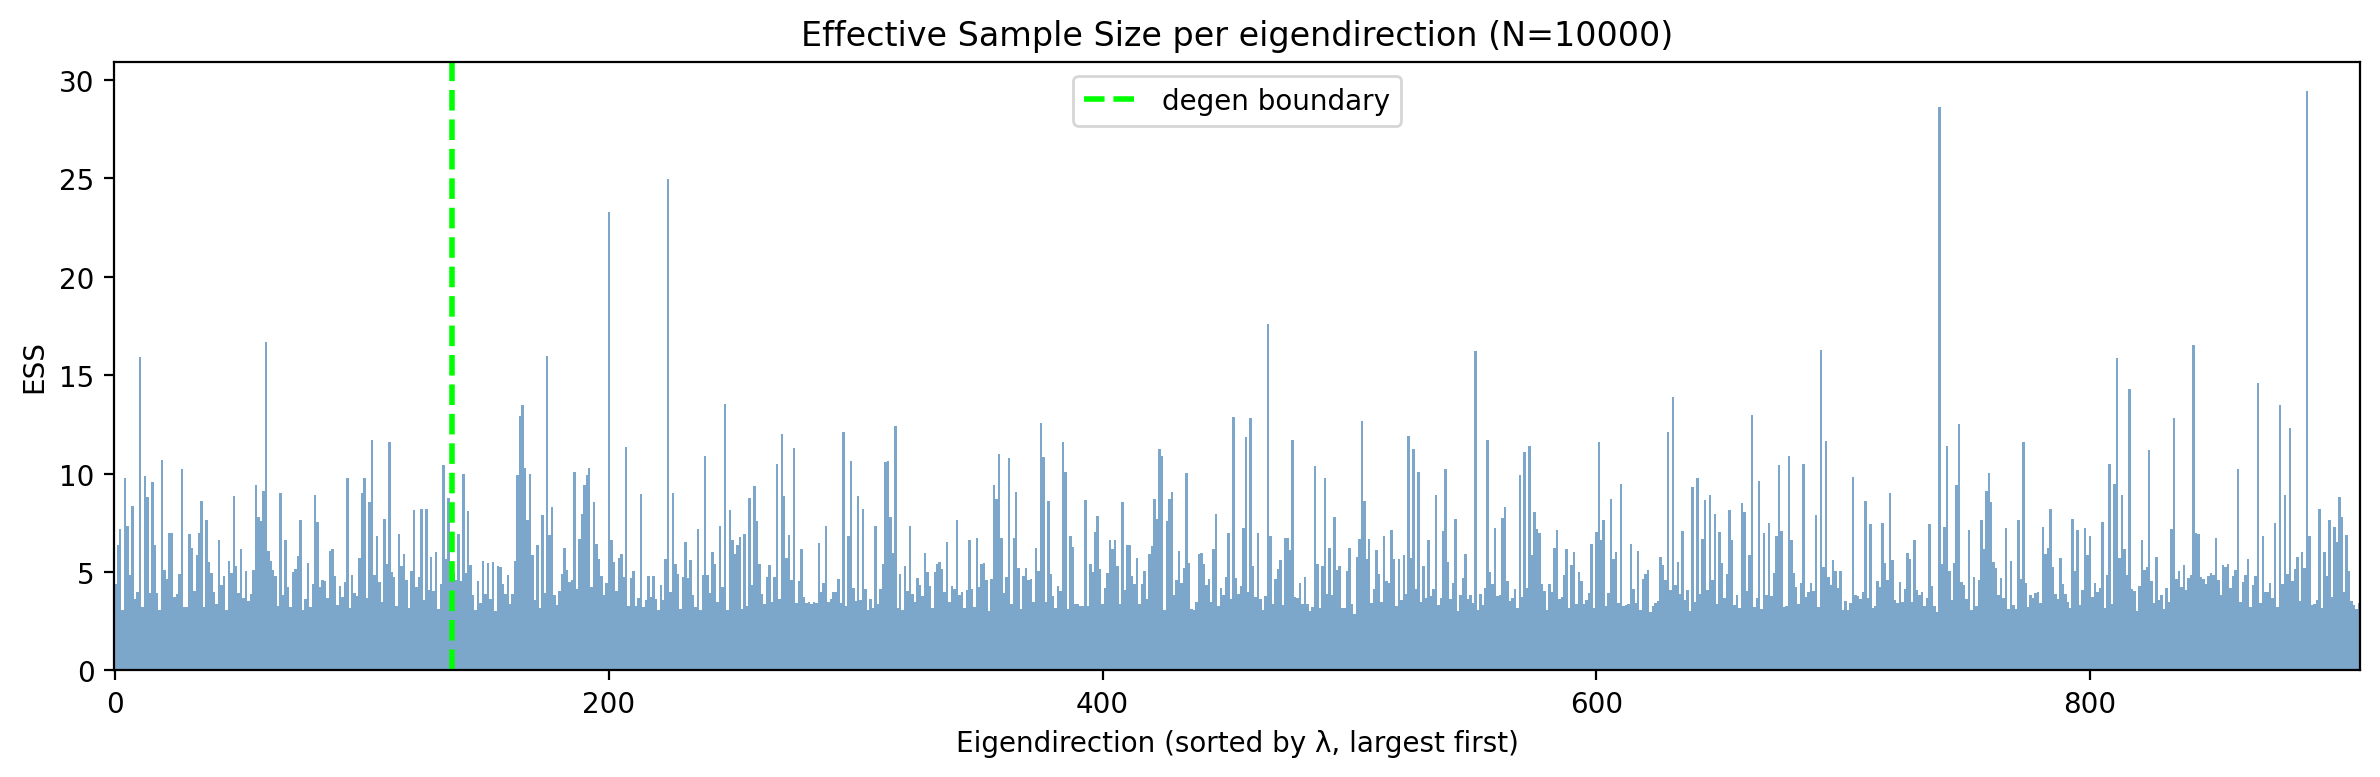

In [78]:
# ── ESS estimate ──
# ESS = N / (1 + 2 * sum_{k=1}^K ACF(k))
# Truncate sum at first negative ACF (Geyer's initial monotone estimator)


def compute_ess(acf_row):
    """Estimate ESS from a single ACF row using initial positive sequence."""
    total = 0.0
    for k in range(acf_row.shape[0]):
        if acf_row[k] < 0:
            break
        total += acf_row[k]
    # ESS = N / (1 + 2*sum) but ACF[0]=1 so subtract that
    tau = 1 + 2 * (total - 1)  # integrated autocorrelation time
    return N_SAMPLES / max(tau, 1.0)


ess_per_dir = torch.tensor(
    [compute_ess(acf_sorted[i]) for i in range(acf_sorted.shape[0])]
)
ess_nd = ess_per_dir[:n_nd]
ess_dg = ess_per_dir[n_nd:]

print(f"ESS across all {acf_sorted.shape[0]} directions:")
print(
    f"  min={ess_per_dir.min():.1f}, median={ess_per_dir.median():.1f}, max={ess_per_dir.max():.1f}"
)
print(f"\nESS non-degenerate ({n_nd} dirs):")
print(f"  min={ess_nd.min():.1f}, median={ess_nd.median():.1f}, max={ess_nd.max():.1f}")
print(f"\nESS degenerate ({n_degen} dirs):")
print(f"  min={ess_dg.min():.1f}, median={ess_dg.median():.1f}, max={ess_dg.max():.1f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    range(len(ess_per_dir)),
    ess_per_dir.numpy(),
    width=1.0,
    color="steelblue",
    alpha=0.7,
)
if 0 < n_nd < len(ess_per_dir):
    ax.axvline(n_nd - 0.5, color="lime", lw=2, ls="--", label="degen boundary")
    ax.legend()
ax.set_xlabel("Eigendirection (sorted by λ, largest first)")
ax.set_ylabel("ESS")
ax.set_title(f"Effective Sample Size per eigendirection (N={N_SAMPLES})")
ax.set_xlim(-0.5, len(ess_per_dir) - 0.5)
plt.tight_layout()
plt.show()

## Verdict

Compare ACF@50 median against success criterion from `.hypothesis`:
- **ACF@50 median < 0.3** → hypothesis falsified, brute-force adaptation works
- **ACF@50 median > 0.5** → hypothesis confirmed, singular geometry defeats any fixed M

In [79]:
# ── Save figures and results ──
import json

RESULTS_DIR = DATA_DIR / "results_no_hessian"
RESULTS_DIR.mkdir(exist_ok=True)

# --- Re-create and save spectral diagnostics figure ---
fig_spec, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(24, 7), sharex=True)

ax_l.plot(
    rank_idx.numpy(), eig_h_sorted.numpy(), color="darkorange", lw=1.5, label="eig(H)"
)
ax_l.plot(
    rank_idx.numpy(),
    eig_Minv_sorted.numpy(),
    color="slateblue",
    lw=1.5,
    ls="--",
    label="eig(M⁻¹)",
)
ax_l.plot(
    rank_idx.numpy(),
    eig_HM_sorted.numpy(),
    color="teal",
    lw=1.5,
    ls="-.",
    label="eig(H·M)",
)
ax_l.axhline(1, color="green", lw=1.0, ls=":", alpha=0.8, label="λ = 1 (ideal)")
ax_l.axhline(0, color="gray", lw=0.8, ls=":")
ax_l.set_yscale("symlog", linthresh=1e-2, linscale=0.5)
ax_l.set_xlabel("Eigenvalue rank (descending)", fontsize=11)
ax_l.set_ylabel("Eigenvalue (symlog)", fontsize=11)
ax_l.set_title(
    "Full spectrum: eig(H), eig(M⁻¹), eig(H·M)", fontsize=12, fontweight="bold"
)
ax_l.grid(True, alpha=0.3)
ax_l.legend(fontsize=10)

ax_r.plot(
    rank_idx.numpy(),
    eig_Htrunc_sorted.clamp(min=1e-12).numpy(),
    color="darkorange",
    lw=1.5,
    label="eig(H₊)",
)
ax_r.plot(
    rank_idx.numpy(),
    eig_Minv_sorted.numpy(),
    color="slateblue",
    lw=1.5,
    ls="--",
    label="eig(M⁻¹)",
)
ax_r.plot(
    rank_idx.numpy(),
    eig_HtruncM_sorted.clamp(min=1e-12).numpy(),
    color="teal",
    lw=1.5,
    ls="-.",
    label="eig(H₊·M)",
)
ax_r.axhline(1, color="green", lw=1.0, ls=":", alpha=0.8, label="λ = 1 (ideal)")
ax_r.set_yscale("log")
ax_r.set_xlabel("Eigenvalue rank (descending)", fontsize=11)
ax_r.set_ylabel("Eigenvalue (log)", fontsize=11)
ax_r.set_title(
    "Truncated H₊ = max(H, 0): eig(H₊), eig(M⁻¹), eig(H₊·M)",
    fontsize=12,
    fontweight="bold",
)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=10)
fig_spec.suptitle(
    "Spectral diagnostics: full vs. positive-truncated Hessian",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
fig_spec.tight_layout()
fig_spec.savefig(RESULTS_DIR / "spectral_diagnostics.pdf", bbox_inches="tight", dpi=150)
fig_spec.savefig(RESULTS_DIR / "spectral_diagnostics.png", bbox_inches="tight", dpi=150)
plt.close(fig_spec)

# --- Re-create and save ACF heatmap ---
fig_acf, ax_acf = plt.subplots(figsize=(16, 8))
im_acf = ax_acf.imshow(
    acf_sorted.numpy(),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=1.0,
    interpolation="nearest",
    origin="upper",
)
ax_acf.set_xlabel("Lag τ", fontsize=12)
ax_acf.set_ylabel("Eigendirection (sorted by λ, largest at top)", fontsize=12)
ax_acf.set_title(
    f"ACF per Hessian eigendirection — NUTS, identity M + adaptation\n"
    f"warmup={N_WARMUP}, {N_SAMPLES} samples, d={mle_param.shape[0]}",
    fontsize=13,
    fontweight="bold",
)
if 0 < n_nd < acf_sorted.shape[0]:
    ax_acf.axhline(
        n_nd - 0.5,
        color="lime",
        lw=2,
        ls="--",
        label=f"degen boundary (top {n_nd} non-degen)",
    )
    ax_acf.legend(loc="upper right", fontsize=10)
plt.colorbar(im_acf, ax=ax_acf, shrink=0.8, label="ACF")
fig_acf.tight_layout()
fig_acf.savefig(RESULTS_DIR / "acf_heatmap.pdf", bbox_inches="tight", dpi=150)
fig_acf.savefig(RESULTS_DIR / "acf_heatmap.png", bbox_inches="tight", dpi=150)
plt.close(fig_acf)

# --- Re-create and save ESS bar chart ---
fig_ess, ax_ess = plt.subplots(figsize=(12, 4))
ax_ess.bar(
    range(len(ess_per_dir)),
    ess_per_dir.numpy(),
    width=1.0,
    color="steelblue",
    alpha=0.7,
)
if 0 < n_nd < len(ess_per_dir):
    ax_ess.axvline(n_nd - 0.5, color="lime", lw=2, ls="--", label="degen boundary")
    ax_ess.legend()
ax_ess.set_xlabel("Eigendirection (sorted by λ, largest first)")
ax_ess.set_ylabel("ESS")
ax_ess.set_title(f"Effective Sample Size per eigendirection (N={N_SAMPLES})")
ax_ess.set_xlim(-0.5, len(ess_per_dir) - 0.5)
fig_ess.tight_layout()
fig_ess.savefig(RESULTS_DIR / "ess_per_direction.pdf", bbox_inches="tight", dpi=150)
fig_ess.savefig(RESULTS_DIR / "ess_per_direction.png", bbox_inches="tight", dpi=150)
plt.close(fig_ess)

# --- Save numerical results ---
results = {
    "experiment": "04_no_hessian",
    "hypothesis": "H1: singular geometry defeats any fixed mass matrix",
    "config": {
        "d": int(mle_param.shape[0]),
        "n_warmup": N_WARMUP,
        "n_samples": N_SAMPLES,
        "max_tree_depth": MAX_TREE_DEPTH,
        "sigma_prior": SIGMA_PRIOR,
        "dgp_regime": DGP_REGIME,
    },
    "spectral": {
        "n_hessian_positive_modes": int((eig_h_sorted > 0).sum()),
        "n_hessian_negative_modes": int((eig_h_sorted < 0).sum()),
        "eig_H_range": [float(eig_h_sorted[-1]), float(eig_h_sorted[0])],
        "eig_Minv_range": [float(eig_Minv_sorted[-1]), float(eig_Minv_sorted[0])],
        "eig_HM_range": [float(eig_HM_sorted[-1]), float(eig_HM_sorted[0])],
        "eig_Htrunc_positive_modes": int(n_Ht_pos),
        "eig_HtruncM_near_one": int(n_HtM_near1),
    },
    "acf": {
        "lag_10_median": float(acf_at_10.median()),
        "lag_50_median": float(acf_at_50.median()),
        "lag_200_median": float(acf_at_200.median()),
        "lag_50_nondegen_median": float(acf50_nd.median()),
        "lag_50_degen_median": float(acf50_dg.median()),
    },
    "ess": {
        "all_min": float(ess_per_dir.min()),
        "all_median": float(ess_per_dir.median()),
        "all_max": float(ess_per_dir.max()),
        "nondegen_min": float(ess_nd.min()),
        "nondegen_median": float(ess_nd.median()),
        "nondegen_max": float(ess_nd.max()),
        "degen_min": float(ess_dg.min()),
        "degen_median": float(ess_dg.median()),
        "degen_max": float(ess_dg.max()),
    },
    "verdict": "confirmed" if float(acf_at_50.median()) > 0.5 else "falsified",
}

with open(RESULTS_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

# Save raw tensors for downstream use
torch.save(
    {
        "eig_h_sorted": eig_h_sorted,
        "eig_Minv_sorted": eig_Minv_sorted,
        "eig_HM_sorted": eig_HM_sorted,
        "eig_Htrunc_sorted": eig_Htrunc_sorted,
        "eig_HtruncM_sorted": eig_HtruncM_sorted,
        "acf_sorted": acf_sorted,
        "ess_per_dir": ess_per_dir,
        "eigvals_sorted": eigvals_sorted,
        "n_nd": n_nd,
        "n_degen": n_degen,
    },
    RESULTS_DIR / "diagnostics_tensors.pt",
)

print(f"✓ Saved to {RESULTS_DIR}/")
print(
    "  Figures: spectral_diagnostics.pdf/png, acf_heatmap.pdf/png, ess_per_direction.pdf/png"
)
print("  Data:    results.json, diagnostics_tensors.pt")
print(f"\n  Verdict: H1 {results['verdict'].upper()}")
print(f"  ACF@50 median = {results['acf']['lag_50_median']:.3f}")
print(f"  ESS median = {results['ess']['all_median']:.1f} / {N_SAMPLES}")

✓ Saved to /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/results_no_hessian/
  Figures: spectral_diagnostics.pdf/png, acf_heatmap.pdf/png, ess_per_direction.pdf/png
  Data:    results.json, diagnostics_tensors.pt

  Verdict: H1 CONFIRMED
  ACF@50 median = 0.968
  ESS median = 4.8 / 10000


## H1-1: Iterative Adaptation Refinement

**Hypothesis H1-1**: Starting from H1's adapted mass matrix (10k warmup),
run additional adaptation rounds (2k warmup + 2k production each). Track how
the eigenspectrum, ACF, and ESS evolve across rounds.

**Prediction**: M will converge (eig(H₊·M) tightens toward 1 in positive modes),
but ESS will plateau quickly (≤ 2–3× improvement) because the mixing bottleneck
is trajectory length in degenerate directions, not M quality. ACF@50 median will
remain > 0.5 across all rounds.

**Protocol**:
- Round 0 = H1 baseline (already computed: 10k warmup, 10k production)
- Rounds 1–K: each does 2k warmup (from previous M) + 2k production
- Save checkpoint after each round: M, ε, spectral/ACF/ESS diagnostics
- Stop when ESS change < 10% between rounds (convergence)

In [ ]:
# ── H1-1 Config ──
N_ROUNDS = 5
N_WARMUP_ITER = 2000
N_SAMPLES_ITER = 2000
MAX_LAG_ITER = min(500, N_SAMPLES_ITER // 4)

ITER_DIR = DATA_DIR / "iterative_adaptation"
ITER_DIR.mkdir(exist_ok=True)

# Load round-0 baseline from H1
iter_mass_matrix = torch.load(MASS_MATRIX_PATH, weights_only=True)
iter_step_size = adapted_step_size

# Hessian eigenbasis for ACF (reuse from earlier cells)
if "eigvecs" not in globals():
    from torch_bdn.bn.bayesian_net import approx_hessian

    H_iter = approx_hessian(model, loss_fn, x_data, y_data, chunk_size=10240).cpu()
    eigvals_iter, eigvecs_iter = torch.linalg.eigh(H_iter)
else:
    eigvals_iter = eigvals
    eigvecs_iter = eigvecs

V_iter = eigvecs_iter.cpu().float()
sort_idx_iter = torch.argsort(eigvals_iter.cpu(), descending=True)
eigval_thresh = eigvals_iter.max().item() * 1e-3
n_nd_iter = int((eigvals_iter.abs() > eigval_thresh).sum())

print(
    f"H1-1: {N_ROUNDS} rounds × ({N_WARMUP_ITER} warmup + {N_SAMPLES_ITER} production)"
)
print(
    f"Starting from H1 mass matrix (cond={torch.linalg.svdvals(iter_mass_matrix)[0] / torch.linalg.svdvals(iter_mass_matrix)[-1]:.1f})"
)
print(
    f"Hessian: {n_nd_iter} non-degen, {eigvals_iter.shape[0] - n_nd_iter} degen directions"
)

In [ ]:
# ── H1-1: Iterative adaptation loop ──
# Each round: warmup (adapt M) → production (fixed M) → diagnostics → checkpoint

round_results = []

for rnd in range(N_ROUNDS):
    print(f"\n{'=' * 70}")
    print(f"ROUND {rnd + 1}/{N_ROUNDS}")
    print(f"{'=' * 70}")

    # ── Warmup: adapt mass matrix ──
    warmup_r = Sampler(bn, x_data, y_data).sample(
        config=NUTS(
            n_warmup=N_WARMUP_ITER,
            step_size=iter_step_size,
            max_tree_depth=MAX_TREE_DEPTH,
            target_accept=0.69,
            mass_matrix=iter_mass_matrix,
            adapt_mass_matrix=True,
        ),
        n_samples=1,
        n_chains=1,
        init_strategy=Perturb(scale=0.1),
        n_cores=1,
    )

    diag_w = warmup_r.chains[0].diagnostics
    new_M = diag_w.get("adapted_mass_matrix")
    new_eps = diag_w.get("adapted_step_size", diag_w["step_size"])

    if new_M is None:
        print(f"  ⚠ Round {rnd + 1}: no adapted M returned, stopping.")
        break

    iter_mass_matrix = new_M
    iter_step_size = new_eps

    # ── Production: fixed M, collect samples ──
    prod_r = Sampler(bn, x_data, y_data).sample(
        config=NUTS(
            n_warmup=0,
            step_size=iter_step_size,
            max_tree_depth=MAX_TREE_DEPTH,
            target_accept=0.69,
            mass_matrix=iter_mass_matrix,
            adapt_mass_matrix=False,
        ),
        n_samples=N_SAMPLES_ITER,
        n_chains=1,
        init_strategy=Perturb(scale=0.1),
        n_cores=1,
    )

    # ── Diagnostics ──
    samps_r = torch.stack(prod_r.chains[0].parameters).cpu().float()

    # ACF
    acf_r = compute_acf_eigenbasis(samps_r, V_iter, MAX_LAG_ITER)[sort_idx_iter]
    acf50_r = acf_r[:, min(50, MAX_LAG_ITER - 1)]

    # ESS
    ess_r = torch.tensor([compute_ess(acf_r[i]) for i in range(acf_r.shape[0])])

    # Spectral: eig(H₊·M)
    M_r_cpu = iter_mass_matrix.detach().cpu().float()
    eigvals_mr, eigvecs_mr = torch.linalg.eigh(M_r_cpu)
    M_sqrt_r = (
        eigvecs_mr @ torch.diag(eigvals_mr.clamp(min=1e-10).sqrt()) @ eigvecs_mr.T
    )
    HtruncM_r = M_sqrt_r @ H_trunc @ M_sqrt_r
    eig_HtM_r = torch.sort(torch.linalg.eigvalsh(HtruncM_r), descending=True).values

    # Summary
    diag_prod = prod_r.chains[0].diagnostics
    n_div_r = diag_prod.get("n_divergences", 0)
    mean_depth_r = diag_prod.get("mean_tree_depth", 0)

    round_info = {
        "round": rnd + 1,
        "step_size": float(iter_step_size),
        "cond_M": float(
            torch.linalg.svdvals(M_r_cpu)[0] / torch.linalg.svdvals(M_r_cpu)[-1]
        ),
        "acf50_median": float(acf50_r.median()),
        "acf50_nd_median": float(acf50_r[:n_nd_iter].median()),
        "acf50_dg_median": float(acf50_r[n_nd_iter:].median()),
        "ess_median": float(ess_r.median()),
        "ess_nd_median": float(ess_r[:n_nd_iter].median()),
        "ess_dg_median": float(ess_r[n_nd_iter:].median()),
        "n_HtM_near1": int(((eig_HtM_r - 1).abs() < 0.5).sum()),
        "n_divergences": n_div_r,
        "mean_tree_depth": float(mean_depth_r),
    }
    round_results.append(round_info)

    # Save checkpoint
    torch.save(
        {
            "mass_matrix": iter_mass_matrix,
            "step_size": iter_step_size,
            "eig_HtruncM": eig_HtM_r,
            "acf_sorted": acf_r,
            "ess_per_dir": ess_r,
            "samples": samps_r,
            "diagnostics": round_info,
        },
        ITER_DIR / f"round_{rnd + 1:02d}.pt",
    )

    print(f"  ε={iter_step_size:.4e}  cond(M)={round_info['cond_M']:.1f}")
    print(
        f"  ACF@50: median={round_info['acf50_median']:.3f} (nd={round_info['acf50_nd_median']:.3f}, dg={round_info['acf50_dg_median']:.3f})"
    )
    print(
        f"  ESS:    median={round_info['ess_median']:.1f} (nd={round_info['ess_nd_median']:.1f}, dg={round_info['ess_dg_median']:.1f})"
    )
    print(f"  eig(H₊·M) near 1: {round_info['n_HtM_near1']}/910")
    print(f"  divergences={n_div_r}, mean_depth={mean_depth_r:.1f}")
    print(f"  ✓ Saved checkpoint → {ITER_DIR / f'round_{rnd + 1:02d}.pt'}")

    # Early stopping: ESS converged
    if len(round_results) >= 2:
        prev_ess = round_results[-2]["ess_median"]
        curr_ess = round_results[-1]["ess_median"]
        pct_change = abs(curr_ess - prev_ess) / max(prev_ess, 1.0)
        if pct_change < 0.10:
            print(f"\n  ★ ESS converged (Δ={pct_change:.1%} < 10%). Stopping early.")
            break

print(f"\n{'=' * 70}")
print(f"H1-1 complete: {len(round_results)} rounds executed")
print(f"Checkpoints saved to {ITER_DIR}/")

In [ ]:
# ── H1-1: Convergence summary plot ──
import json

rounds = [r["round"] for r in round_results]
acf50s = [r["acf50_median"] for r in round_results]
acf50_nds = [r["acf50_nd_median"] for r in round_results]
ess_meds = [r["ess_median"] for r in round_results]
ess_nd_meds = [r["ess_nd_median"] for r in round_results]
n_near1s = [r["n_HtM_near1"] for r in round_results]
conds = [r["cond_M"] for r in round_results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ACF@50 convergence
axes[0, 0].plot(rounds, acf50s, "o-", color="teal", lw=2, label="all")
axes[0, 0].plot(rounds, acf50_nds, "s--", color="darkorange", lw=1.5, label="non-degen")
axes[0, 0].axhline(0.5, color="red", ls=":", lw=1, label="H1 threshold")
axes[0, 0].set_xlabel("Round")
axes[0, 0].set_ylabel("ACF@50 median")
axes[0, 0].set_title("ACF@50 across rounds")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(0, 1.05)

# ESS convergence
axes[0, 1].plot(rounds, ess_meds, "o-", color="steelblue", lw=2, label="all")
axes[0, 1].plot(
    rounds, ess_nd_meds, "s--", color="darkorange", lw=1.5, label="non-degen"
)
axes[0, 1].axhline(
    N_SAMPLES_ITER, color="green", ls=":", lw=1, alpha=0.5, label=f"N={N_SAMPLES_ITER}"
)
axes[0, 1].set_xlabel("Round")
axes[0, 1].set_ylabel("ESS median")
axes[0, 1].set_title("ESS across rounds")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# eig(H₊·M) near 1
axes[1, 0].plot(rounds, n_near1s, "o-", color="purple", lw=2)
axes[1, 0].set_xlabel("Round")
axes[1, 0].set_ylabel("# modes with eig(H₊·M) ∈ [0.5, 1.5]")
axes[1, 0].set_title("Spectral match improvement")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 910)

# Condition number
axes[1, 1].plot(rounds, conds, "o-", color="crimson", lw=2)
axes[1, 1].set_xlabel("Round")
axes[1, 1].set_ylabel("cond(M)")
axes[1, 1].set_title("Mass matrix conditioning")
axes[1, 1].set_yscale("log")
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("H1-1: Iterative Adaptation Convergence", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(ITER_DIR / "convergence_summary.pdf", bbox_inches="tight", dpi=150)
fig.savefig(ITER_DIR / "convergence_summary.png", bbox_inches="tight", dpi=150)
plt.show()

# Save tabular summary
with open(ITER_DIR / "round_summary.json", "w") as f:
    json.dump(round_results, f, indent=2)

# Print table
print(
    f"\n{'Round':<6} {'ACF@50':<8} {'ACF@50(nd)':<11} {'ESS':<8} {'ESS(nd)':<9} {'#near1':<7} {'cond(M)':<10}"
)
print("-" * 65)
for r in round_results:
    print(
        f"{r['round']:<6} {r['acf50_median']:<8.3f} {r['acf50_nd_median']:<11.3f} "
        f"{r['ess_median']:<8.1f} {r['ess_nd_median']:<9.1f} {r['n_HtM_near1']:<7} {r['cond_M']:<10.1f}"
    )

# Verdict
final_acf = round_results[-1]["acf50_median"]
final_ess = round_results[-1]["ess_median"]
print("\n★ H1-1 Verdict:")
print(
    f"  Final ACF@50 median = {final_acf:.3f} {'> 0.5 → CONFIRMED' if final_acf > 0.5 else '< 0.5 → NEEDS MORE INVESTIGATION'}"
)
print(f"  Final ESS median = {final_ess:.1f} / {N_SAMPLES_ITER}")
if len(round_results) >= 2:
    ess_gain = round_results[-1]["ess_median"] / max(
        round_results[0]["ess_median"], 0.1
    )
    print(f"  ESS gain from round 1 → {len(round_results)}: {ess_gain:.2f}×")
print(
    f"  Conclusion: {'More warmup does NOT fix mixing' if final_acf > 0.5 else 'More warmup DOES help'}"
)